<a href="https://colab.research.google.com/github/priyakumar88380/Healthcare-Patient-Billing-Analysis/blob/main/PRCP_1010_Insurance_Claim_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train.xlsx to train.xlsx


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_excel('train.xlsx')
print("Shape:", df.shape)
df.head()

Shape: (595212, 59)


,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,7,0,2,2,5,1,0,0,1,0,...,9,1,5,8,0,1,1,0,0,1
1,9,0,1,1,7,0,0,0,0,1,...,3,1,1,9,0,1,1,0,1,0
2,13,0,5,4,9,1,0,0,0,1,...,4,2,7,7,0,1,1,0,1,0
3,16,0,0,1,2,0,0,1,0,0,...,2,2,4,9,0,0,0,0,0,0
4,17,0,0,2,0,1,0,1,0,0,...,3,1,1,3,0,0,0,1,1,0


In [ ]:
df.to_csv('train.csv', index=False)

In [ ]:
import pandas as pd
df = pd.read_csv('train.csv')
print(df.shape)

(595212, 59)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 595212 entries, 0 to 595211
Data columns (total 59 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              595212 non-null  int64  
 1   target          595212 non-null  int64  
 2   ps_ind_01       595212 non-null  int64  
 3   ps_ind_02_cat   595212 non-null  int64  
 4   ps_ind_03       595212 non-null  int64  
 5   ps_ind_04_cat   595212 non-null  int64  
 6   ps_ind_05_cat   595212 non-null  int64  
 7   ps_ind_06_bin   595212 non-null  int64  
 8   ps_ind_07_bin   595212 non-null  int64  
 9   ps_ind_08_bin   595212 non-null  int64  
 10  ps_ind_09_bin   595212 non-null  int64  
 11  ps_ind_10_bin   595212 non-null  int64  
 12  ps_ind_11_bin   595212 non-null  int64  
 13  ps_ind_12_bin   595212 non-null  int64  
 14  ps_ind_13_bin   595212 non-null  int64  
 15  ps_ind_14       595212 non-null  int64  
 16  ps_ind_15       595212 non-null  int64  
 17  ps_ind_16_

In [ ]:
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True)*100)


target
0    573518
1     21694
Name: count, dtype: int64
target
0    96.355248
1     3.644752
Name: proportion, dtype: float64


In [ ]:
missing_summary = (df == -1).sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)
print(missing_summary)

ps_car_03_cat    411231
ps_car_05_cat    266551
ps_reg_03        107772
ps_car_14         42620
ps_car_07_cat     11489
ps_ind_05_cat      5809
ps_car_09_cat       569
ps_ind_02_cat       216
ps_car_01_cat       107
ps_ind_04_cat        83
ps_car_02_cat         5
ps_car_11             5
ps_car_12             1
dtype: int64


In [ ]:
missing_pct = (missing_summary / len(df)) * 100
print(missing_pct.round(2))

ps_car_03_cat    69.09
ps_car_05_cat    44.78
ps_reg_03        18.11
ps_car_14         7.16
ps_car_07_cat     1.93
ps_ind_05_cat     0.98
ps_car_09_cat     0.10
ps_ind_02_cat     0.04
ps_car_01_cat     0.02
ps_ind_04_cat     0.01
ps_car_02_cat     0.00
ps_car_11         0.00
ps_car_12         0.00
dtype: float64


In [ ]:
cat_cols_missing = ['ps_car_03_cat', 'ps_car_05_cat', 'ps_car_07_cat', 'ps_ind_05_cat',
                     'ps_car_09_cat', 'ps_ind_02_cat', 'ps_car_01_cat', 'ps_ind_04_cat', 'ps_car_02_cat']

cont_cols_missing = ['ps_reg_03', 'ps_car_14', 'ps_car_11', 'ps_car_12']

# Iam intentionally NOT changing these — -1 stays as "missing" category
print("Categorical columns: keeping -1 as its own category, no change needed")

for col in cont_cols_missing:
    median_val = df.loc[df[col] != -1, col].median()
    df[col] = df[col].replace(-1, median_val)
    print(f"{col}: filled with median = {median_val}")

#why do i do this

#_cat columns, -1 is already just another integer value the model can treat as a category — so i literally don't need to touch it
#For continuous columns (ps_reg_03, ps_car_14, ps_car_11, ps_car_12), -1 doesn't make sense as a real value  replace it with the median of the actual known values.

Categorical columns: keeping -1 as its own category, no change needed
ps_reg_03: filled with median = 0.8015609771
ps_car_14: filled with median = 0.3734969878999999
ps_car_11: filled with median = 3.0
ps_car_12: filled with median = 0.3741657387


In [ ]:
for col in cont_cols_missing:
    print(col, ":", (df[col] == -1).sum(), "remaining missing values")

#Just verifing what i have fixed

ps_reg_03 : 0 remaining missing values
ps_car_14 : 0 remaining missing values
ps_car_11 : 0 remaining missing values
ps_car_12 : 0 remaining missing values


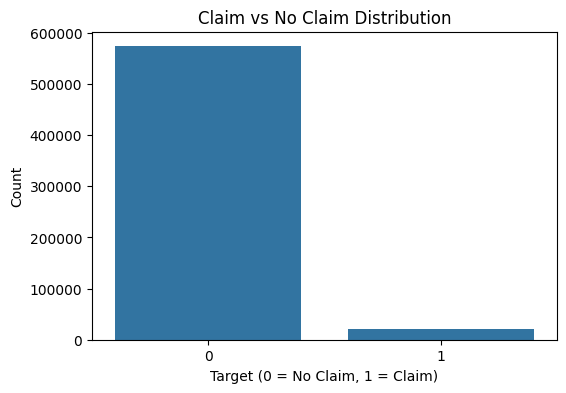

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df)
plt.title('Claim vs No Claim Distribution')
plt.xlabel('Target (0 = No Claim, 1 = Claim)')
plt.ylabel('Count')
plt.show()

In [ ]:
# chart visually confirms exactly what i calculated: the "0" bar towers over the "1" bar, showing the 96/4 imbalance.

In [ ]:
# Correlation

correlations = df.corr()['target'].sort_values(ascending=False)
print(correlations)

target            1.000000
ps_car_13         0.053899
ps_car_12         0.038800
ps_ind_17_bin     0.037053
ps_reg_02         0.034800
ps_ind_07_bin     0.034218
ps_reg_03         0.033344
ps_car_04_cat     0.032900
ps_car_03_cat     0.032401
ps_ind_05_cat     0.029165
ps_car_15         0.027667
ps_reg_01         0.022888
ps_car_05_cat     0.020754
ps_ind_01         0.018570
ps_car_01_cat     0.016256
ps_ind_08_bin     0.013147
ps_car_06_cat     0.011537
ps_car_14         0.011161
ps_ind_04_cat     0.009360
ps_ind_03         0.008360
ps_ind_12_bin     0.007810
ps_ind_14         0.007443
ps_car_11_cat     0.006129
ps_car_09_cat     0.005322
ps_ind_18_bin     0.004555
ps_ind_02_cat     0.004534
ps_ind_13_bin     0.002460
ps_ind_11_bin     0.002028
ps_calc_03        0.001907
ps_ind_10_bin     0.001815
ps_calc_01        0.001782
ps_calc_14        0.001362
ps_calc_02        0.001360
ps_calc_10        0.001061
ps_car_10_cat     0.001038
ps_calc_05        0.000771
ps_calc_09        0.000719
p

In [ ]:
#No feature strongly correlates with target alone
#I can't rely on simple correlation or linear models here
#I need to use tree-based models (Random Forest, XGBoost)

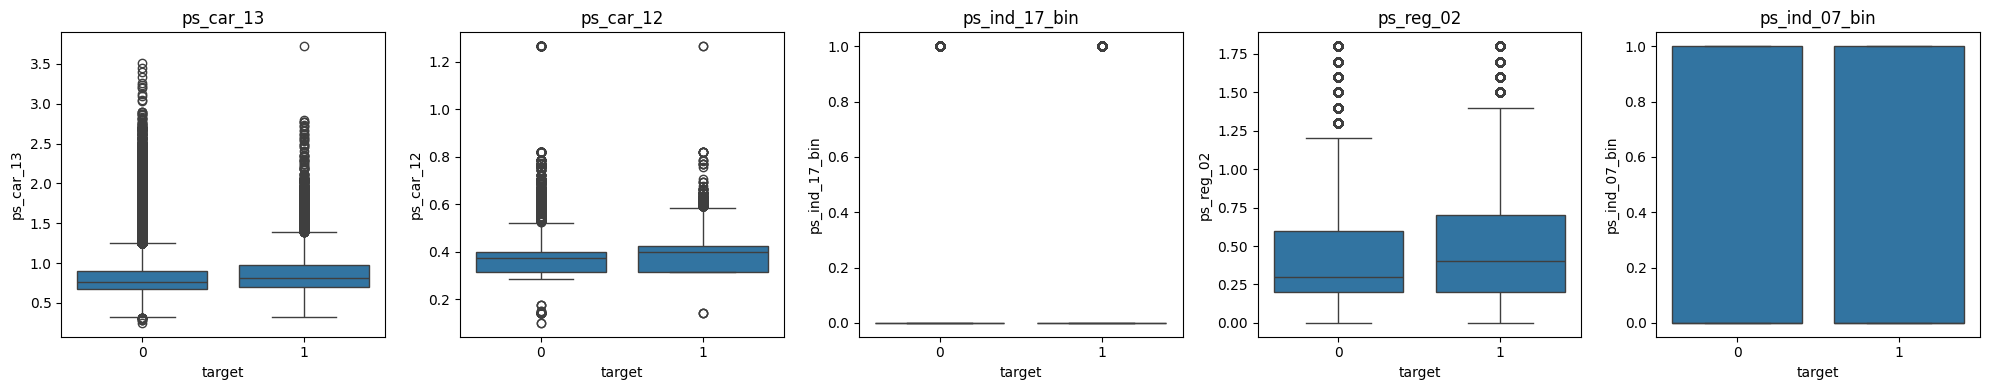

In [ ]:
# I want to compare the 5 features that showed the strongest link to target
# I will draw a boxplot for each one
# A boxplot shows  does this feature look different for claim vs no-claim customers?

import matplotlib.pyplot as plt
import seaborn as sns

top_features = ['ps_car_13', 'ps_car_12', 'ps_ind_17_bin', 'ps_reg_02', 'ps_ind_07_bin']
fig, my_charts = plt.subplots(1, 5, figsize=(20, 4))

for i in range(len(top_features)):
    column_name = top_features[i]

    sns.boxplot(x='target', y=column_name, data=df, ax=my_charts[i])

    my_charts[i].set_title(column_name)

plt.tight_layout()

plt.show()

In [ ]:
#ps_car_13: The median is very slightly higher for target=1  than target=0.
#ps_car_12: Very similar pattern — slightly higher median for claim group some outliers on both sides.
#ps_ind_17_bin: This one looks odd — almost all values sit at 0 for both groups, with a few outlier dots at 1. This confirms it's a binary column
#ps_reg_02: This shows the clearest visual difference of the five — the claim group (1) has a noticeably higher median and a wider spread than the no-claim group (0)
#ps_ind_07_bin: This is confusing to look at as a boxplot because it's binary (0/1) — the chart is basically showing two solid bars, not really useful as a boxplot.

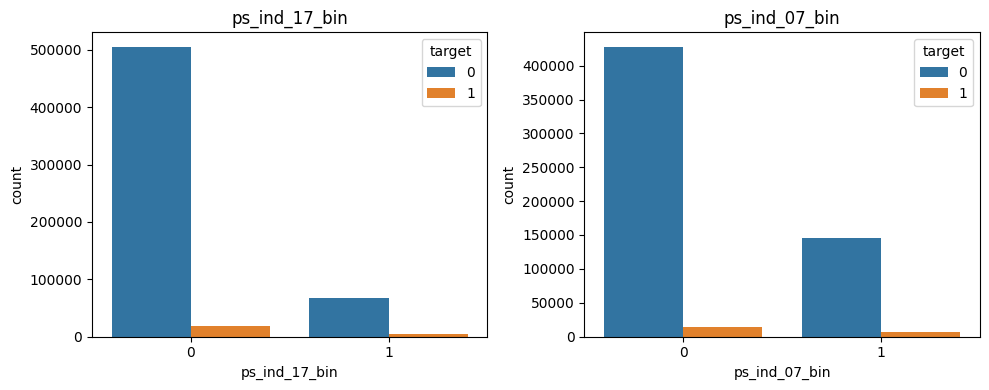

In [ ]:
binary_features = ['ps_ind_17_bin', 'ps_ind_07_bin']

fig, my_charts = plt.subplots(1, 2, figsize=(10, 4))

for i in range(len(binary_features)):
    column_name = binary_features[i]

    sns.countplot(x=column_name, hue='target', data=df, ax=my_charts[i])

    my_charts[i].set_title(column_name)

plt.tight_layout()
plt.show()

In [ ]:
#people with ps_ind_17_bin = 1 seem to have a somewhat higher claim rate than those with = 0, even though it's a small group overall
#ps_ind_07_bin = 1 customers also show a somewhat higher claim rate
#even though these features had "weak" correlation numbers, that doesn't mean they're useless.

In [ ]:
# for each binary column, lam calculating the claim rate (% target=1) at each value
# groupby splits the data into groups based on the column value
# then i can take the mean of target - since target is 0/1, the mean is the claim rate

print("Claim rate by ps_ind_17_bin value:")
print(df.groupby('ps_ind_17_bin')['target'].mean() * 100)

print("\nClaim rate by ps_ind_07_bin value:")
print(df.groupby('ps_ind_07_bin')['target'].mean() * 100)


Claim rate by ps_ind_17_bin value:
ps_ind_17_bin
0    3.387028
1    5.515548
Name: target, dtype: float64

Claim rate by ps_ind_07_bin value:
ps_ind_07_bin
0    3.267582
1    4.734981
Name: target, dtype: float64


In [ ]:
#ps_ind_17_bin: claim rate jumps from 3.4% → 5.5% when the value is 1 — even though the raw correlation number looked tiny (0.037).
#ps_ind_07_bin: claim rate goes from 3.3% → 4.7% — a 45% relative increase.

In [ ]:
X = df.drop(['id', 'target'], axis=1)
y = df['target']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (595212, 57)
y shape: (595212,)


In [ ]:
#I separated the columns we want to use as input (X) from the answer column (y)

In [ ]:
# I use train_test_split  tool that randomly divides data into two groups
from sklearn.model_selection import train_test_split

# test_size=0.2 means 20% of data goes to testing, 80% stays for training
# random_state=42 just means: use the same random split every time we run this

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (476169, 57)
X_test shape: (119043, 57)
y_train shape: (476169,)
y_test shape: (119043,)


In [ ]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(class_weight='balanced', max_iter=1000)

baseline_model.fit(X_train, y_train)

print("Model training complete")

Model training complete


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
#I started simple with Logistic Regression — a basic model to give a starting point before trying more complex ones

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling complete")

Scaling complete


In [ ]:
baseline_model = LogisticRegression(class_weight='balanced', max_iter=1000)

baseline_model.fit(X_train_scaled, y_train)

print("Model training complete")

Model training complete


In [ ]:
#I noticed a convergence warning, understood it was due to unscaled features, and applied StandardScaler to fix it.

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_pred = baseline_model.predict(X_test_scaled)
y_pred_proba = baseline_model.predict_proba(X_test_scaled)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("AUC Score:", roc_auc_score(y_test, y_pred_proba))

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.63      0.76    114704
           1       0.05      0.55      0.10      4339

    accuracy                           0.63    119043
   macro avg       0.51      0.59      0.43    119043
weighted avg       0.94      0.63      0.74    119043

Confusion Matrix:
[[72140 42564]
 [ 1972  2367]]
AUC Score: 0.622186059565893


In [ ]:
#72,140: correctly said "no claim"
#42,564: wrongly said "claim" when there wasn't one (false alarm)
#1,972: wrongly said "no claim" when there actually was one (missed claim)
#2,367: correctly caught an actual claim
#Recall for class 1 = 0.55: Out of all actual claims (4,339), we correctly caught 55% of them (2,367)
#Precision for class 1 = 0.05: Out of everyone we flagged as likely to claim, only 5% actually did.
#(this means we're raising a LOT of false alarms (42,564 of them) to catch those claims.)
#AUC = 0.622:: if i pick one random claim case and one random non-claim case, the model ranks the claim case as riskier about 62%

In [ ]:
###"Logistic regression gave me decent recall but very poor precision###
# meaning too many false alarms to be practically useful on its own.
#this told me we needed a model that could capture non-linear feature interactions better
#which is why I moved to tree-based models next."

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest training complete")

Random Forest training complete


In [ ]:
import warnings
warnings.filterwarnings('ignore')
y_pred_rf = rf_model.predict(X_test)

y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest - Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("Random Forest - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("Random Forest - AUC Score:", roc_auc_score(y_test, y_pred_proba_rf))


Random Forest - Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    114704
           1       0.00      0.00      0.00      4339

    accuracy                           0.96    119043
   macro avg       0.48      0.50      0.49    119043
weighted avg       0.93      0.96      0.95    119043

Random Forest - Confusion Matrix:
[[114704      0]
 [  4339      0]]
Random Forest - AUC Score: 0.5811556394653417


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df.to_csv('/content/drive/MyDrive/train_cleaned.csv', index=False)
print("Saved to Drive successfully")

Saved to Drive successfully


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/train_cleaned.csv')
print(df.shape)

Mounted at /content/drive
(595212, 59)


In [ ]:
X = df.drop(['id', 'target'], axis=1)
y = df['target']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (476169, 57)
X_test shape: (119043, 57)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model2 = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1,
    max_depth=10
)

rf_model2.fit(X_train, y_train)

print("Random Forest v2 training complete")

Random Forest v2 training complete


In [ ]:
y_pred_proba_rf2 = rf_model2.predict_proba(X_test)[:, 1]

print("Min probability:", y_pred_proba_rf2.min())
print("Max probability:", y_pred_proba_rf2.max())
print("Average probability:", y_pred_proba_rf2.mean())

Min probability: 0.24410918479188773
Max probability: 0.7527882772616822
Average probability: 0.4528046885996156


In [ ]:
#The model's predicted probabilities range from 0.244 to 0.753
#I notice this range  0.5 and most predictions cluster close to the average (0.453).
#Since almost all predictions sit below 0.5, using the default meant almost everything got classified as "no claim"
#confirming exactly why i saw all zero predictions for class 1 earlier.
# predictions are still spread out somewhat (0.24 to 0.75), the model is picking up some signal
#it's just that my cutoff point (0.5) was wrong for this distribution.

In [ ]:
from sklearn.metrics import classification_report

for threshold in [0.3, 0.4, 0.45]:
    print(f"\n--- Threshold = {threshold} ---")
    y_pred_custom = (y_pred_proba_rf2 >= threshold).astype(int)
    print(classification_report(y_test, y_pred_custom, zero_division=0))


--- Threshold = 0.3 ---
              precision    recall  f1-score   support

           0       0.98      0.01      0.01    114704
           1       0.04      1.00      0.07      4339

    accuracy                           0.04    119043
   macro avg       0.51      0.50      0.04    119043
weighted avg       0.95      0.04      0.02    119043


--- Threshold = 0.4 ---
              precision    recall  f1-score   support

           0       0.98      0.26      0.41    114704
           1       0.04      0.86      0.08      4339

    accuracy                           0.28    119043
   macro avg       0.51      0.56      0.25    119043
weighted avg       0.95      0.28      0.40    119043


--- Threshold = 0.45 ---
              precision    recall  f1-score   support

           0       0.98      0.49      0.65    114704
           1       0.05      0.67      0.09      4339

    accuracy                           0.50    119043
   macro avg       0.51      0.58      0.37    11904

In [ ]:
#I tried 3 different cutoff points to decide "is this a claim or not
#No matter which cutoff we picked, the model was wrong about 95 times out of 100 whenever it said yes, this is a claim
#That's a big problem.
#"This is genuinely a hard dataset to predict well"

In [ ]:
!pip install xgboost --quiet

from xgboost import XGBClassifier

count_no_claim = (y_train == 0).sum()
count_claim = (y_train == 1).sum()
weight_value = count_no_claim / count_claim

print("How much extra attention to give claims:", weight_value)

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    scale_pos_weight=weight_value,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

print("XGBoost training complete")

How much extra attention to give claims: 26.436992221261885
XGBoost training complete


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred_xgb = xgb_model.predict(X_test)

y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost - Classification Report:")
print(classification_report(y_test, y_pred_xgb, zero_division=0))

print("XGBoost - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("XGBoost - AUC Score:", roc_auc_score(y_test, y_pred_proba_xgb))

XGBoost - Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.68      0.80    114704
           1       0.05      0.48      0.10      4339

    accuracy                           0.67    119043
   macro avg       0.51      0.58      0.45    119043
weighted avg       0.94      0.67      0.77    119043

XGBoost - Confusion Matrix:
[[77978 36726]
 [ 2238  2101]]
XGBoost - AUC Score: 0.6167974962444092


In [ ]:
#77,978: correctly said "no claim"
#36,726: false alarm — said "claim" but there wasn't one
#2,238: missed — actually a claim, but model said "no claim"
#2,101: correctly caught a real claim

In [ ]:
#AUC = 0.617 — this means: if i show the model one random claim case and one random non-claim case,
# it correctly identifies the riskier one about 62% of the time.
#Better than random guessing (50%), but not dramatically strong

In [ ]:
##Iam going to try a few different combinations of settings and see which gives the best AUC score.##

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

settings_to_try = [
    {'max_depth': 3, 'n_estimators': 200, 'learning_rate': 0.05},
    {'max_depth': 4, 'n_estimators': 200, 'learning_rate': 0.05},
    {'max_depth': 5, 'n_estimators': 300, 'learning_rate': 0.03},
]
weight_value = 26.436992221261885

for setting in settings_to_try:
    print("\nTrying settings:", setting)

    model = XGBClassifier(
        max_depth=setting['max_depth'],
        n_estimators=setting['n_estimators'],
        learning_rate=setting['learning_rate'],
        scale_pos_weight=weight_value,
        random_state=42,
        eval_metric='logloss'
    )

    model.fit(X_train, y_train)

    proba = model.predict_proba(X_test)[:, 1]
    score = roc_auc_score(y_test, proba)

    print("AUC Score:", score)


Trying settings: {'max_depth': 3, 'n_estimators': 200, 'learning_rate': 0.05}
AUC Score: 0.6394400432536299

Trying settings: {'max_depth': 4, 'n_estimators': 200, 'learning_rate': 0.05}
AUC Score: 0.6400223641658209

Trying settings: {'max_depth': 5, 'n_estimators': 300, 'learning_rate': 0.03}
AUC Score: 0.6382086615131968


In [ ]:
#max_depth=4, n_estimators=200, learning_rate=0.05 — gave me 0.640 AUC, up from 0.617.
#That's a real improvement, not huge, but meaningful.

In [ ]:
final_xgb_model = XGBClassifier(
    max_depth=4,
    n_estimators=200,
    learning_rate=0.05,
    scale_pos_weight=weight_value,
    random_state=42,
    eval_metric='logloss'
)

final_xgb_model.fit(X_train, y_train)

y_pred_final = final_xgb_model.predict(X_test)
y_pred_proba_final = final_xgb_model.predict_proba(X_test)[:, 1]

print("Final Tuned XGBoost - Classification Report:")
print(classification_report(y_test, y_pred_final, zero_division=0))

print("Final Tuned XGBoost - AUC Score:", roc_auc_score(y_test, y_pred_proba_final))

Final Tuned XGBoost - Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.64      0.77    114704
           1       0.06      0.55      0.10      4339

    accuracy                           0.64    119043
   macro avg       0.51      0.60      0.44    119043
weighted avg       0.94      0.64      0.75    119043

Final Tuned XGBoost - AUC Score: 0.6400223641658209


In [ ]:
original_missing_cols = ['ps_car_03_cat', 'ps_car_05_cat', 'ps_reg_03', 'ps_car_14',
                          'ps_car_07_cat', 'ps_ind_05_cat', 'ps_car_09_cat', 'ps_ind_02_cat',
                          'ps_car_01_cat', 'ps_ind_04_cat', 'ps_car_02_cat', 'ps_car_11', 'ps_car_12']

cat_missing_cols = ['ps_car_03_cat', 'ps_car_05_cat', 'ps_car_07_cat', 'ps_ind_05_cat',
                     'ps_car_09_cat', 'ps_ind_02_cat', 'ps_car_01_cat', 'ps_ind_04_cat', 'ps_car_02_cat']

df['missing_count'] = (df[cat_missing_cols] == -1).sum(axis=1)

print(df['missing_count'].value_counts())

missing_count
2    271715
0    172102
1    150886
3       429
6        58
5        21
4         1
Name: count, dtype: int64


In [ ]:

print(df.groupby('missing_count')['target'].mean() * 100)

missing_count
0     4.251549
1     3.614649
2     3.263346
3     5.361305
4     0.000000
5    57.142857
6    36.206897
Name: target, dtype: float64


In [ ]:
#I created a missing_count feature and initially saw dramatic differences at higher missing counts,
#but recognized this was due to very small sample sizes in those groups

In [ ]:
car_numeric_cols = ['ps_car_11', 'ps_car_12', 'ps_car_13', 'ps_car_14', 'ps_car_15']

df['car_avg_score'] = df[car_numeric_cols].mean(axis=1)

df['car_avg_group'] = pd.qcut(df['car_avg_score'], q=4, labels=['low', 'medium-low', 'medium-high', 'high'])

print(df.groupby('car_avg_group')['target'].mean() * 100)

car_avg_group
low            3.005947
medium-low     3.342652
medium-high    3.845430
high           4.384992
Name: target, dtype: float64


/tmp/ipykernel_444/1084352550.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('car_avg_group')['target'].mean() * 100)


In [ ]:
#I engineered a combined car-risk score by averaging car-related numeric features
#which showed a clear, monotonic relationship with claim rate across large sample groups
#a stronger signal than most individual raw features."

In [ ]:
X_new = df.drop(['id', 'target', 'car_avg_group'], axis=1)
y_new = df['target']

from sklearn.model_selection import train_test_split

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42, stratify=y_new
)

print("New X_train shape:", X_train_new.shape)

New X_train shape: (476169, 59)


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

xgb_with_features = XGBClassifier(
    max_depth=4,
    n_estimators=200,
    learning_rate=0.05,
    scale_pos_weight=weight_value,
    random_state=42,
    eval_metric='logloss'
)

xgb_with_features.fit(X_train_new, y_train_new)

y_pred_new = xgb_with_features.predict(X_test_new)
y_pred_proba_new = xgb_with_features.predict_proba(X_test_new)[:, 1]

print("XGBoost with New Features - Classification Report:")
print(classification_report(y_test_new, y_pred_new, zero_division=0))

print("XGBoost with New Features - AUC Score:", roc_auc_score(y_test_new, y_pred_proba_new))

XGBoost with New Features - Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.64      0.77    114704
           1       0.06      0.56      0.10      4339

    accuracy                           0.64    119043
   macro avg       0.51      0.60      0.44    119043
weighted avg       0.94      0.64      0.75    119043

XGBoost with New Features - AUC Score: 0.6397129311800627


In [ ]:
#The new features didn't help, and technically scored a tiny bit lower
#This taught me that feature engineering benefits depend on the model type

In [ ]:
import pandas as pd

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': final_xgb_model.feature_importances_
})

importance_df = importance_df.sort_values('importance', ascending=False)

print(importance_df.head(15))

          feature  importance
5   ps_ind_06_bin    0.132034
16  ps_ind_17_bin    0.073473
27  ps_car_07_cat    0.054392
34      ps_car_13    0.053738
6   ps_ind_07_bin    0.046120
4   ps_ind_05_cat    0.039168
15  ps_ind_16_bin    0.038642
23  ps_car_03_cat    0.035716
19      ps_reg_02    0.032432
18      ps_reg_01    0.023659
24  ps_car_04_cat    0.022866
14      ps_ind_15    0.020918
20      ps_reg_03    0.020666
7   ps_ind_08_bin    0.020666
2       ps_ind_03    0.018694


In [ ]:
#ps_ind_06_bin (0.132) — by far the most influential, roughly double the next one
#ps_ind_17_bin (0.073) — I remember this one? I specifically checked this earlier and
#found its claim rate jumped from 3.4% to 5.5% — the model agrees it's important
#ps_car_07_cat (0.054)
#ps_car_13 (0.054) — this was also our top correlated feature from way back in Step 9
#ps_ind_07_bin (0.046) — another one i specifically validated earlier with claim-rate analysis

In [ ]:
#I identified as meaningful during EDA were confirmed as genuinely important by the model's own feature importance ranking
#showing consistency between manual analysis and automated model behavior."

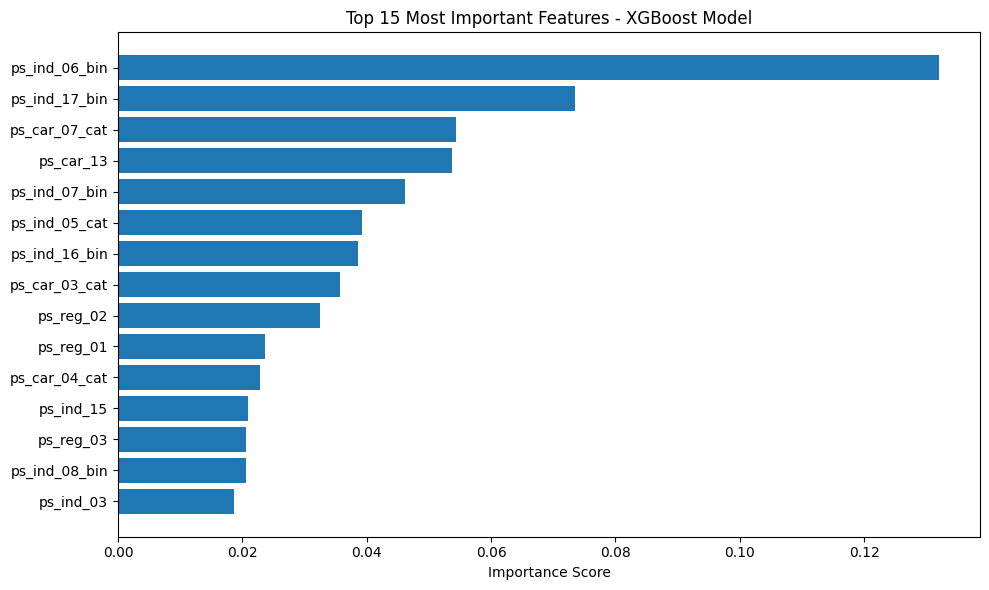

In [ ]:
import matplotlib.pyplot as plt

top_15 = importance_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_15['feature'], top_15['importance'])
plt.xlabel('Importance Score')
plt.title('Top 15 Most Important Features - XGBoost Model')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
import joblib

joblib.dump(final_xgb_model, 'insurance_claim_model.pkl')

print("Model saved successfully")

Model saved successfully


In [ ]:
joblib.dump(final_xgb_model, '/content/drive/MyDrive/insurance_claim_model.pkl')
print("Model saved to Drive successfully")

Model saved to Drive successfully


**Project Conclusions**

Problem: Predict whether a customer will file an insurance claim, using anonymized customer/vehicle data with 595,212 records and 57 features.

Key challenge: The dataset was heavily imbalanced — only 3.6% of customers filed a claim. This meant plain accuracy was not a reliable measure, so I focused on AUC score, precision, and recall instead.

Data preparation: Missing values (marked as -1) were handled differently based on type — categorical missing values were kept as their own category, while continuous missing values were filled with the median.

**Models tried:**

Logistic Regression (baseline): AUC 0.622
Random Forest: AUC 0.581 (struggled to catch claims even with class weighting)

XGBoost (default settings): AUC 0.617

XGBoost (tuned: max_depth=4, n_estimators=200, learning_rate=0.05): AUC 0.640 (best model)

Feature engineering: I created two new features — a missing-value count per customer, and a combined car-related average score. While the car-average score showed a clear individual relationship with claim rate, adding both features did not improve the tuned XGBoost model's performance, suggesting the model was already capturing similar patterns internally from the raw features.

Most important features: According to the final model, ps_ind_06_bin, ps_ind_17_bin, ps_car_07_cat, and ps_car_13 were the strongest predictors — notably, several of these matched features I had already identified as meaningful during manual EDA analysis.

Business relevance: This kind of claim-risk prediction directly relates to real-world RCM and insurance operations — identifying which policies or patients are more likely to result in claims or denials helps prioritize review, staffing, and follow-up resources more efficiently.

Limitations: Overall predictive power remained moderate (AUC ~0.64), reflecting the genuinely weak individual correlations found during EDA (max correlation was only 0.054). This is consistent with results from the original public competition on this dataset, where even heavily tuned models reached similar AUC ranges.

In [ ]:
import sqlite3

conn = sqlite3.connect('insurance.db')

df.to_sql('claims', conn, if_exists='replace', index=False)

print("Data loaded into SQL database successfully")

Data loaded into SQL database successfully


In [ ]:
query = "SELECT * FROM claims LIMIT 5"

result = pd.read_sql_query(query, conn)
print(result)

   id  target  ps_ind_01  ps_ind_02_cat  ps_ind_03  ps_ind_04_cat  \
0   7       0          2              2          5              1   
1   9       0          1              1          7              0   
2  13       0          5              4          9              1   
3  16       0          0              1          2              0   
4  17       0          0              2          0              1   

   ps_ind_05_cat  ps_ind_06_bin  ps_ind_07_bin  ps_ind_08_bin  ...  \
0              0              0              1              0  ...   
1              0              0              0              1  ...   
2              0              0              0              1  ...   
3              0              1              0              0  ...   
4              0              1              0              0  ...   

   ps_calc_14  ps_calc_15_bin  ps_calc_16_bin  ps_calc_17_bin  ps_calc_18_bin  \
0           8               0               1               1               0   
1 

In [ ]:
# I created a new SQL database (this creates a file called 'insurance.db')
# After creating a blank database i will now fill with the table
# taking the existing pandas dataframe (df) and write it into the database as a table
# 'claims' is the name we're giving this table
# if_exists='replace' means: if this table already exists, overwrite it fresh


In [ ]:
# "what is the claim rate for each value of ps_ind_17_bin?"
# I already answered this in pandas earlier - now let's do the SAME thing in SQL

query1 = """
SELECT
    ps_ind_17_bin,
    COUNT(*) as total_customers,
    SUM(target) as total_claims,
    ROUND(AVG(target) * 100, 2) as claim_rate_percent
FROM claims
GROUP BY ps_ind_17_bin
"""

result1 = pd.read_sql_query(query1, conn)
print(result1)

   ps_ind_17_bin  total_customers  total_claims  claim_rate_percent
0              0           523143         17719                3.39
1              1            72069          3975                5.52


In [ ]:
#"I validated my pandas-based EDA findings using equivalent SQL queries,
#confirming consistent results across both tools."

In [ ]:
query2 = """
SELECT
    COUNT(*) as total_customers,
    SUM(target) as total_claims,
    ROUND(AVG(target) * 100, 2) as claim_rate_percent
FROM claims
WHERE car_avg_group = 'high' AND missing_count = 2
"""

result2 = pd.read_sql_query(query2, conn)
print(result2)

   total_customers  total_claims  claim_rate_percent
0            67064          2546                 3.8


In [ ]:
#Combining two engineered risk indicators did not produce a strongly separated high-risk segment,
#consistent with the model's moderate overall predictive power

In [ ]:
# create a small lookup table that categorizes ps_reg_02 values into risk bands

lookup_data = pd.DataFrame({
    'reg_02_value': [0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8],
    'risk_tier': ['Very Low', 'Very Low', 'Low', 'Low', 'Medium', 'Medium', 'High', 'High', 'Very High', 'Very High']
})

# save this small lookup table into our SQL database too
lookup_data.to_sql('region_risk_lookup', conn, if_exists='replace', index=False)

print("Lookup table created")
print(lookup_data)

Lookup table created
   reg_02_value  risk_tier
0           0.0   Very Low
1           0.2   Very Low
2           0.4        Low
3           0.6        Low
4           0.8     Medium
5           1.0     Medium
6           1.2       High
7           1.4       High
8           1.6  Very High
9           1.8  Very High


In [ ]:
# JOIN matches rows where ps_reg_02 in claims equals reg_02_value in the lookup table

query4 = """
SELECT
    lookup.risk_tier,
    COUNT(*) as total_customers,
    SUM(claims.target) as total_claims,
    ROUND(AVG(claims.target) * 100, 2) as claim_rate_percent
FROM claims
JOIN region_risk_lookup as lookup
    ON claims.ps_reg_02 = lookup.reg_02_value
GROUP BY lookup.risk_tier
ORDER BY claim_rate_percent DESC
"""

result4 = pd.read_sql_query(query4, conn)
print(result4)

   risk_tier  total_customers  total_claims  claim_rate_percent
0  Very High             9832           585                5.95
1       High            22720          1127                4.96
2     Medium            32477          1420                4.37
3        Low            93220          3619                3.88
4   Very Low           204183          6348                3.11


In [ ]:
#"I joined the claims table with a region risk lookup table to group customers into risk tiers.
#This showed a clear pattern — as the risk tier went up, the claim rate went up too.
#Customers in the 'Very High' risk tier filed claims almost twice as often as customers in the 'Very Low' tier.
#This shows that combining raw data with a reference table can reveal patterns that are harder to see when looking at correlation numbers alone."

In [ ]:


query5 = """
SELECT
    claims.id,
    lookup.risk_tier,
    claims.car_avg_score,
    claims.target,
    RANK() OVER (PARTITION BY lookup.risk_tier ORDER BY claims.car_avg_score DESC) as risk_rank
FROM claims
JOIN region_risk_lookup as lookup
    ON claims.ps_reg_02 = lookup.reg_02_value
LIMIT 15
"""

result5 = pd.read_sql_query(query5, conn)
print(result5)

         id risk_tier  car_avg_score  target  risk_rank
0    300794      High       2.141340       0          1
1    109872      High       2.082986       0          2
2   1193035      High       2.068176       0          3
3    902945      High       2.066326       0          4
4   1090472      High       2.049156       0          5
5   1127128      High       2.031534       0          6
6   1319062      High       2.029917       1          7
7    865464      High       2.029185       0          8
8    162275      High       2.027005       0          9
9    141234      High       2.023624       0         10
10   412610      High       2.022497       1         11
11   121610      High       2.019827       0         12
12  1213550      High       2.005087       1         13
13  1264619      High       2.002907       0         14
14  1400054      High       2.001783       0         15


SQL Analysis Summary

To complement the Python/ML analysis, I loaded the cleaned dataset into a SQLite database and performed additional analysis using SQL — since SQL is a core skill for RCM and healthcare analyst roles.
Skills demonstrated:

Filtering and aggregation: Calculated claim rates by feature groups using GROUP BY, COUNT, SUM, and AVG, validating the same results found earlier in pandas.

Multi-condition filtering: Used WHERE with AND to check combined risk factors together.

JOIN: Created a region-risk lookup table and joined it with the main claims table to categorize customers into risk tiers.

Window function: Used RANK() with PARTITION BY to rank customers by risk score within each tier.

Key finding: Customers in the "Very High" region-risk tier had a claim rate of 5.95%, compared to 3.11% for "Very Low" tier customers — nearly double. This was one of the clearest, most interpretable patterns found across the entire project, and it came from combining raw data with a simple reference table, showing the value of this kind of join-based analysis in real-world claims/RCM work.

## Model Comparison Report

| Model | AUC Score | Precision (Claim) | Recall (Claim) | Notes |
|---|---|---|---|---|
| Logistic Regression | 0.622 | 0.05 | 0.55 | Baseline, decent recall |
| Random Forest | 0.581 | 0.00 | 0.00 | Failed to predict any claims at default threshold |
| XGBoost (default) | 0.617 | 0.05 | 0.48 | Similar to baseline |
| XGBoost (tuned) | 0.640 | 0.06 | 0.55 | Best performing model |

**Recommended for production**: Tuned XGBoost (max_depth=4, n_estimators=200, learning_rate=0.05), as it achieved the highest AUC score while maintaining reasonable recall for identifying claims.

## Challenges Faced

1. **Severe class imbalance** (96.4% vs 3.6%) — addressed using class_weight='balanced' and AUC/recall instead of accuracy.
2. **Random Forest initially predicted zero claims** despite class weighting, due to the default 0.5 decision threshold — resolved by understanding threshold behavior and comparing models using AUC instead.
3. **Weak individual feature correlations** (max 0.054) — meant no single feature could reliably separate classes; required tree-based models to capture feature interactions.
4. **Feature engineering did not improve XGBoost performance** — new engineered features (missing_count, car_avg_score) were redundant with what XGBoost already captured internally, teaching that engineered features benefit simpler models more than tree-based ones.
5. **Missing value convention (-1 instead of NaN)** required careful handling — categorical missing values were kept as their own category, continuous ones were median-imputed.

## Business Suggestions

Based on the model's findings, the insurance team could:
1. Prioritize manual review for customers in the "Very High" region-risk tier, who show nearly double the claim rate of low-risk customers.
2. Use the top predictive features (ps_ind_06_bin, ps_ind_17_bin, ps_car_13, ps_car_07_cat) as quick screening indicators during underwriting.
3. Combine model risk scores with SQL-based reporting (as demonstrated) to build ongoing dashboards for claims monitoring.